# Sentiment Analysis & Emotion Detection Project

1. Classify text as positive / negative / neutral
2. Detect specific emotions using an NLP lexicon (NRC)
3. Apply analysis across mixed social-text sources (app reviews, social/political commentary)
4. Surface public-opinion / sentiment-pattern trends
5. Translate results into marketing / product / social insights


In [8]:
import re
import json
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

!pip install nrclex -qq
from nrclex.core import _load_bundled_lexicon

sns.set_theme(style="whitegrid")
OUT = "/home/claude/sentiment_project"

## 1. Load & Clean

In [9]:
df = pd.read_csv("/content/sentiment_data.csv")
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")])
df = df.dropna(subset=["Comment"]).reset_index(drop=True)
df["Comment"] = df["Comment"].astype(str).str.strip()
df = df[df["Comment"].str.len() > 0].reset_index(drop=True)

LABEL_MAP = {0: "Negative", 1: "Positive", 2: "Neutral"}
df["SentimentLabel"] = df["Sentiment"].map(LABEL_MAP)

print("Rows after cleaning:", len(df))
print(df["SentimentLabel"].value_counts())

Rows after cleaning: 240928
SentimentLabel
Neutral     103046
Positive     82777
Negative     55105
Name: count, dtype: int64


## 2. EDA: Class Distribution & Text Length

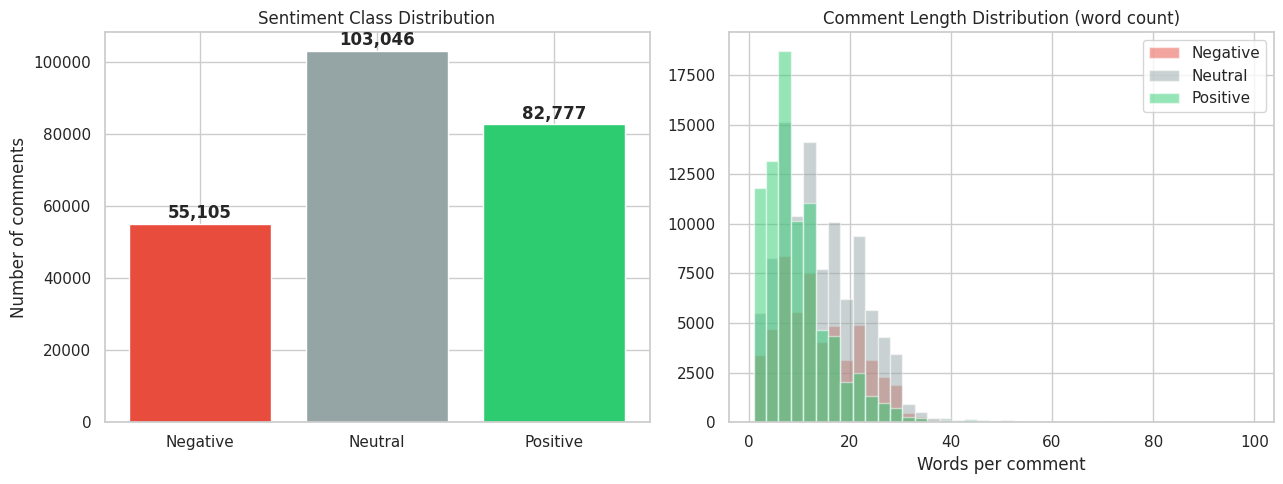

In [10]:
import os

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = ["Negative", "Neutral", "Positive"]
colors = {"Negative": "#e74c3c", "Neutral": "#95a5a6", "Positive": "#2ecc71"}
counts = df["SentimentLabel"].value_counts().reindex(order)
axes[0].bar(order, counts.values, color=[colors[o] for o in order])
axes[0].set_title("Sentiment Class Distribution")
axes[0].set_ylabel("Number of comments")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1500, f"{v:,}", ha="center", fontweight="bold")

df["word_count"] = df["Comment"].str.split().apply(len)
for lab in order:
    subset = df[df["SentimentLabel"] == lab]["word_count"]
    axes[1].hist(subset[subset < 100], bins=40, alpha=0.5, label=lab, color=colors[lab])
axes[1].set_title("Comment Length Distribution (word count)")
axes[1].set_xlabel("Words per comment")
axes[1].legend()
plt.tight_layout()
os.makedirs(OUT, exist_ok=True)
plt.savefig(f"{OUT}/01_eda_overview.png", dpi=150)
plt.show()

### Word Clouds per Sentiment

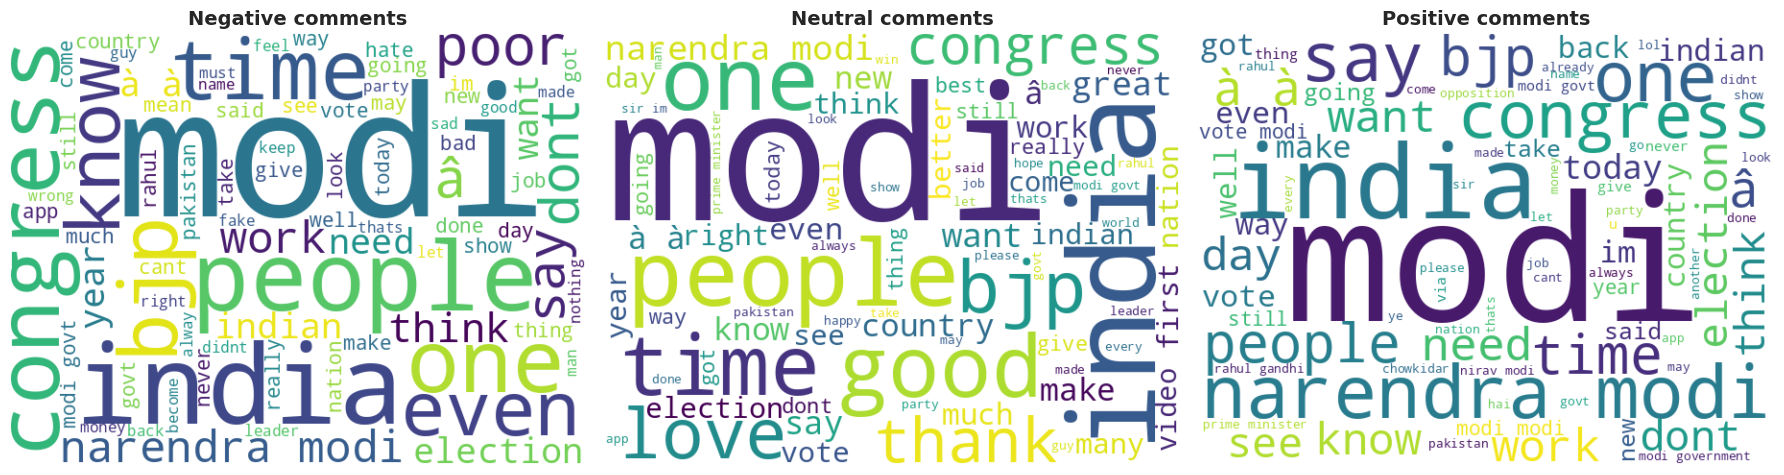

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, lab in zip(axes, order):
    text = " ".join(df[df["SentimentLabel"] == lab]["Comment"].sample(
        min(20000, (df["SentimentLabel"] == lab).sum()), random_state=42))
    wc = WordCloud(width=600, height=450, background_color="white",
                   colormap="viridis", max_words=80).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{lab} comments", fontsize=14, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUT}/02_wordclouds.png", dpi=150)
plt.show()


## 3. Classification Model (TF-IDF + Logistic Regression / Naive Bayes)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    df["Comment"], df["Sentiment"], test_size=0.2, random_state=42, stratify=df["Sentiment"]
)

vectorizer = TfidfVectorizer(max_features=25000, ngram_range=(1, 2), min_df=3)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=5, class_weight="balanced"),
    "Multinomial Naive Bayes": MultinomialNB(),
}

results = {}
best_name, best_model, best_acc = None, None, -1
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    results[name] = {"accuracy": acc, "macro_f1": f1, "preds": preds}
    print(f"\n{name}: accuracy={acc:.4f}  macro-F1={f1:.4f}")
    print(classification_report(y_test, preds, target_names=["Negative", "Positive", "Neutral"]))
    if acc > best_acc:
        best_acc, best_name, best_model = acc, name, model

print(f"\nBest model: {best_name} (accuracy={best_acc:.4f})")



Logistic Regression: accuracy=0.7848  macro-F1=0.7774
              precision    recall  f1-score   support

    Negative       0.71      0.75      0.73     11021
    Positive       0.75      0.81      0.78     16556
     Neutral       0.86      0.78      0.82     20609

    accuracy                           0.78     48186
   macro avg       0.78      0.78      0.78     48186
weighted avg       0.79      0.78      0.79     48186


Multinomial Naive Bayes: accuracy=0.6796  macro-F1=0.6599
              precision    recall  f1-score   support

    Negative       0.76      0.50      0.60     11021
    Positive       0.67      0.62      0.64     16556
     Neutral       0.66      0.82      0.74     20609

    accuracy                           0.68     48186
   macro avg       0.70      0.65      0.66     48186
weighted avg       0.69      0.68      0.67     48186


Best model: Logistic Regression (accuracy=0.7848)


### Confusion Matrix — Best Model

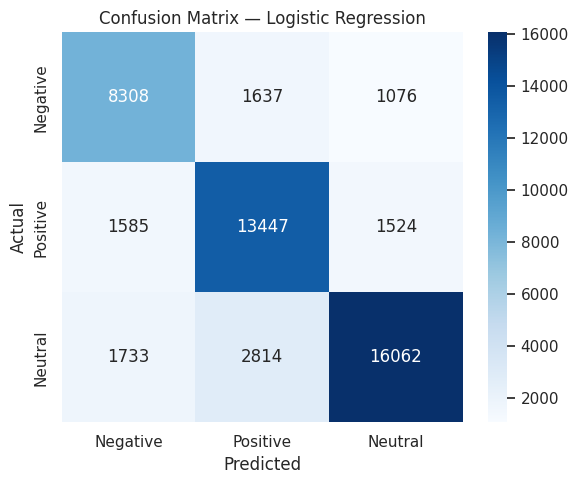

In [14]:
cm = confusion_matrix(y_test, results[best_name]["preds"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive", "Neutral"],
            yticklabels=["Negative", "Positive", "Neutral"])
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{OUT}/03_confusion_matrix.png", dpi=150)
plt.show()


### Model Comparison

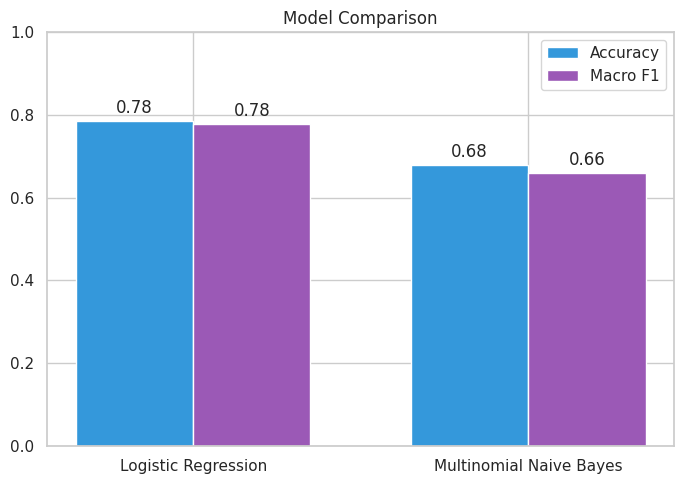

In [15]:
plt.figure(figsize=(7, 5))
names = list(results.keys())
accs = [results[n]["accuracy"] for n in names]
f1s = [results[n]["macro_f1"] for n in names]
x = np.arange(len(names))
w = 0.35
plt.bar(x - w/2, accs, w, label="Accuracy", color="#3498db")
plt.bar(x + w/2, f1s, w, label="Macro F1", color="#9b59b6")
plt.xticks(x, names)
plt.ylim(0, 1)
plt.title("Model Comparison")
plt.legend()
for i, (a, f) in enumerate(zip(accs, f1s)):
    plt.text(i - w/2, a + 0.02, f"{a:.2f}", ha="center")
    plt.text(i + w/2, f + 0.02, f"{f:.2f}", ha="center")
plt.tight_layout()
plt.savefig(f"{OUT}/04_model_comparison.png", dpi=150)
plt.show()


## 4. Emotion Detection (NRC Lexicon) — Fast Vectorised Lookup

In [16]:
LEXICON = _load_bundled_lexicon()
EMOTIONS = ["anger", "anticipation", "disgust", "fear", "joy",
            "sadness", "surprise", "trust"]

def emotion_counts(text):
    counts = Counter()
    for word in text.split():
        tags = LEXICON.get(word)
        if tags:
            for t in tags:
                if t in EMOTIONS:
                    counts[t] += 1
    return counts

# Run on a stratified sample of ~45,000 comments for speed (adjust as needed)
sample_df = pd.concat(
    [g.sample(min(len(g), 15000), random_state=42) for _, g in df.groupby("SentimentLabel")]
).reset_index(drop=True)

emo_rows = []
for text, lab in zip(sample_df["Comment"], sample_df["SentimentLabel"]):
    c = emotion_counts(text)
    row = {e: c.get(e, 0) for e in EMOTIONS}
    row["SentimentLabel"] = lab
    emo_rows.append(row)

emo_df = pd.DataFrame(emo_rows)
emo_by_sentiment = emo_df.groupby("SentimentLabel")[EMOTIONS].sum()
emo_by_sentiment_norm = emo_by_sentiment.div(emo_by_sentiment.sum(axis=1), axis=0)

overall_emotion = emo_df[EMOTIONS].sum()
overall_emotion_norm = overall_emotion / overall_emotion.sum()


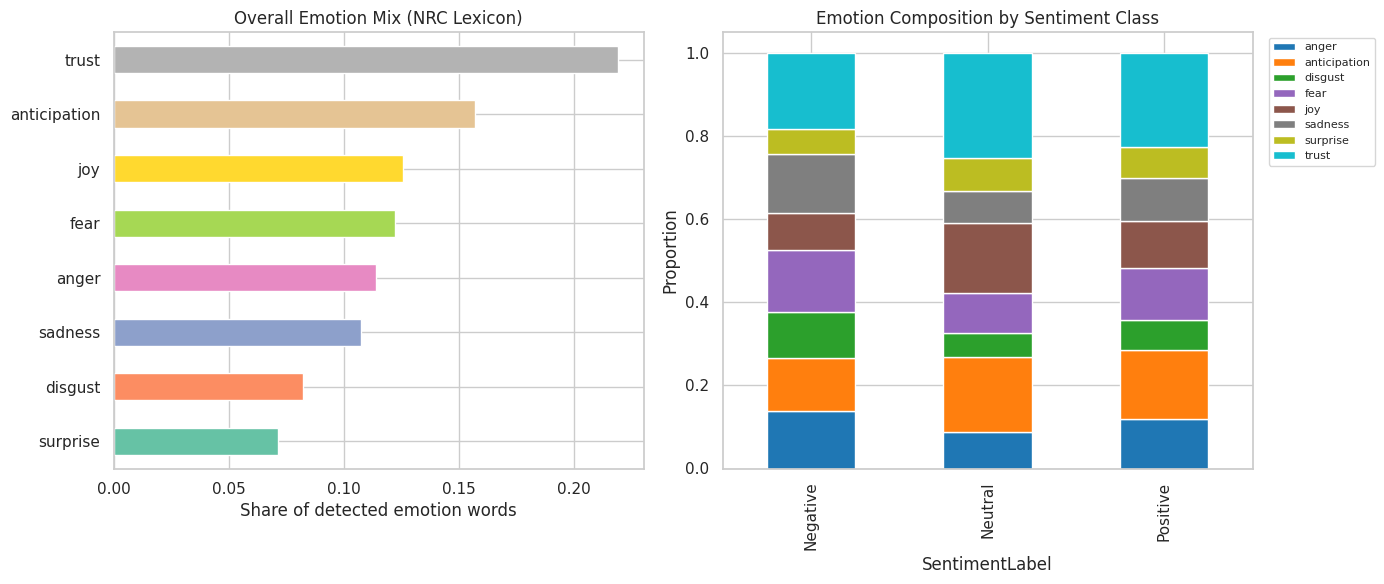

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
overall_emotion_norm.sort_values(ascending=True).plot(
    kind="barh", ax=axes[0], color=sns.color_palette("Set2", len(EMOTIONS)))
axes[0].set_title("Overall Emotion Mix (NRC Lexicon)")
axes[0].set_xlabel("Share of detected emotion words")

emo_by_sentiment_norm.reindex(order).plot(
    kind="bar", stacked=True, ax=axes[1], colormap="tab10")
axes[1].set_title("Emotion Composition by Sentiment Class")
axes[1].set_ylabel("Proportion")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT}/05_emotion_analysis.png", dpi=150)
plt.show()


## 5. Save Key Numbers for the Report

In [18]:
summary = {
    "total_comments": int(len(df)),
    "sentiment_counts": df["SentimentLabel"].value_counts().to_dict(),
    "sentiment_pct": (df["SentimentLabel"].value_counts(normalize=True) * 100).round(1).to_dict(),
    "best_model": best_name,
    "best_accuracy": round(best_acc, 4),
    "model_results": {k: {"accuracy": round(v["accuracy"], 4), "macro_f1": round(v["macro_f1"], 4)}
                       for k, v in results.items()},
    "overall_emotion_pct": (overall_emotion_norm * 100).round(1).to_dict(),
    "emotion_by_sentiment_pct": (emo_by_sentiment_norm * 100).round(1).to_dict(orient="index"),
}

with open(f"{OUT}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved summary.json and charts.")
print(json.dumps(summary, indent=2))



Saved summary.json and charts.
{
  "total_comments": 240928,
  "sentiment_counts": {
    "Neutral": 103046,
    "Positive": 82777,
    "Negative": 55105
  },
  "sentiment_pct": {
    "Neutral": 42.8,
    "Positive": 34.4,
    "Negative": 22.9
  },
  "best_model": "Logistic Regression",
  "best_accuracy": 0.7848,
  "model_results": {
    "Logistic Regression": {
      "accuracy": 0.7848,
      "macro_f1": 0.7774
    },
    "Multinomial Naive Bayes": {
      "accuracy": 0.6796,
      "macro_f1": 0.6599
    }
  },
  "overall_emotion_pct": {
    "anger": 11.4,
    "anticipation": 15.7,
    "disgust": 8.2,
    "fear": 12.2,
    "joy": 12.6,
    "sadness": 10.8,
    "surprise": 7.1,
    "trust": 21.9
  },
  "emotion_by_sentiment_pct": {
    "Negative": {
      "anger": 13.9,
      "anticipation": 12.8,
      "disgust": 11.1,
      "fear": 14.9,
      "joy": 9.0,
      "sadness": 14.1,
      "surprise": 6.0,
      "trust": 18.3
    },
    "Neutral": {
      "anger": 8.7,
      "anticipation"